First, we import all the libraries : 

In [ ]:
import pandas as pd
import kaggle
import psycopg2
import os
import missingno as msno
import matplotlib.pyplot as plt
from io import StringIO
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
import plotly.express as px


In [ ]:

file_path =r'C:\PostgreSQL\Data\input\auto-insurance-claims-data\insurance_claims.csv'

In [ ]:
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The Csv file has not been found :{file_path}")

with open(file_path,'r') as fh:
    first_line=fh.readline()

sep=';' if first_line.count(';')>first_line.count(';')else','
df=pd.read_csv(file_path,sep=',')

-Let's visualize the shape of our file, its size, and its separator.

In [ ]:
print(f"Loaded: {file_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Separator: '{sep}'")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

df

Loaded: C:\PostgreSQL\Data\input\auto-insurance-claims-data\insurance_claims.csv
Shape: 1,000 rows × 40 columns
Separator: ','
Memory: 1.3 MB


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


Since we understand the meaning of the columns in this case, it facilitates the process of Exploratory Data Analysis

We can drop unnecessary Columns like "_c39"

In [ ]:
df.drop("_c39",axis=1,inplace=True)


Visualizing missing values is crucial to understand data quality. Missingno provides an excellent way to graphically display the distribution of NaN values, making it easy to identify which columns or rows have incomplete data. It's a handy tool for assessing data completeness in Pandas : 

In [67]:
df['collision_type'] = df['collision_type'].fillna(df['collision_type'].mode()[0])
df['property_damage'] = df['property_damage'].fillna(df['property_damage'].mode()[0])
df['police_report_available'] = df['police_report_available'].fillna(df['police_report_available'].mode()[0])

df.isna().sum()


months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

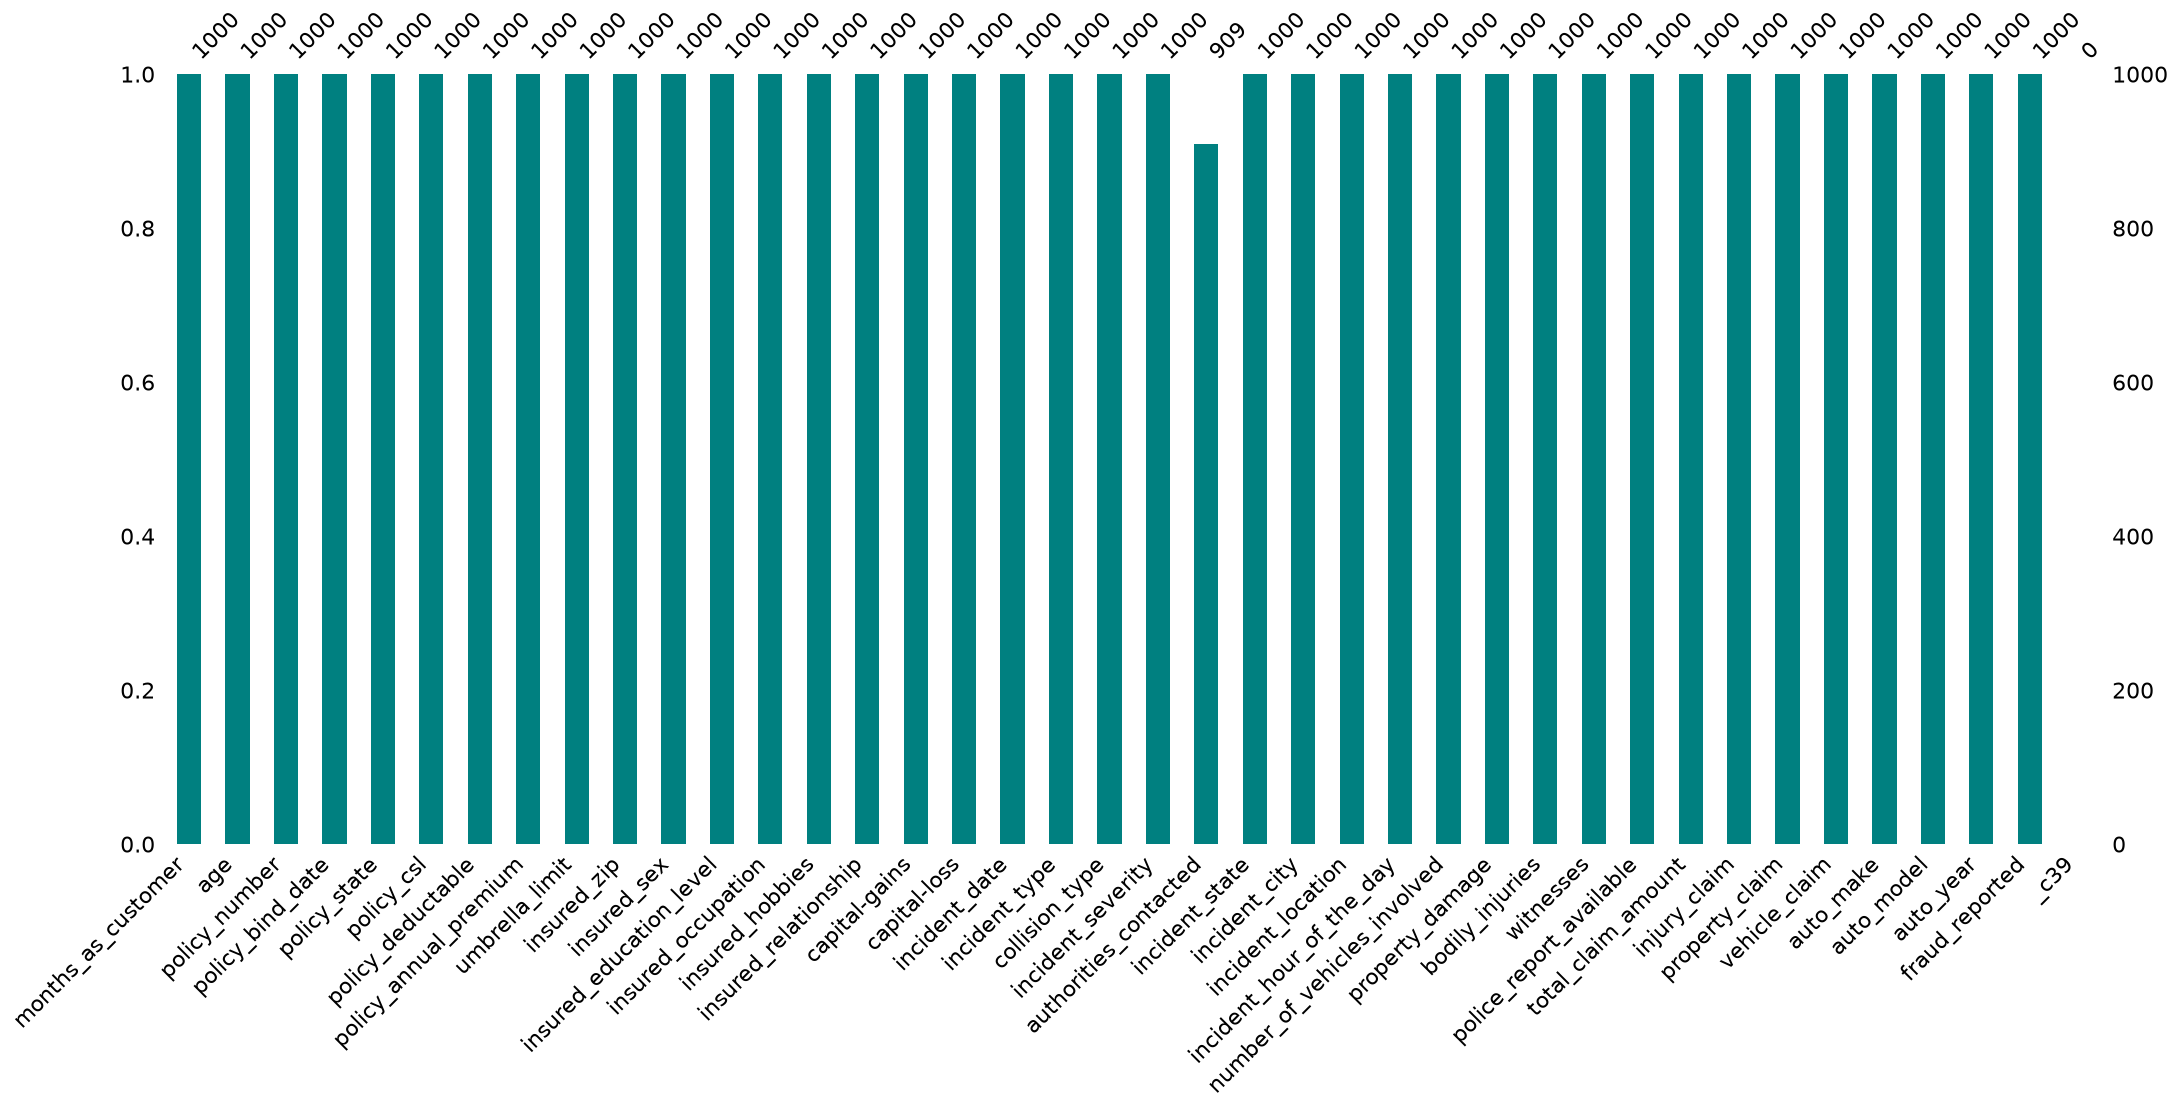

In [69]:
msno.bar(df, color='teal')
plt.show()

Finally, we can see all the missing values in our dataset with this graph

-Now, let's examine the correlations within our data.

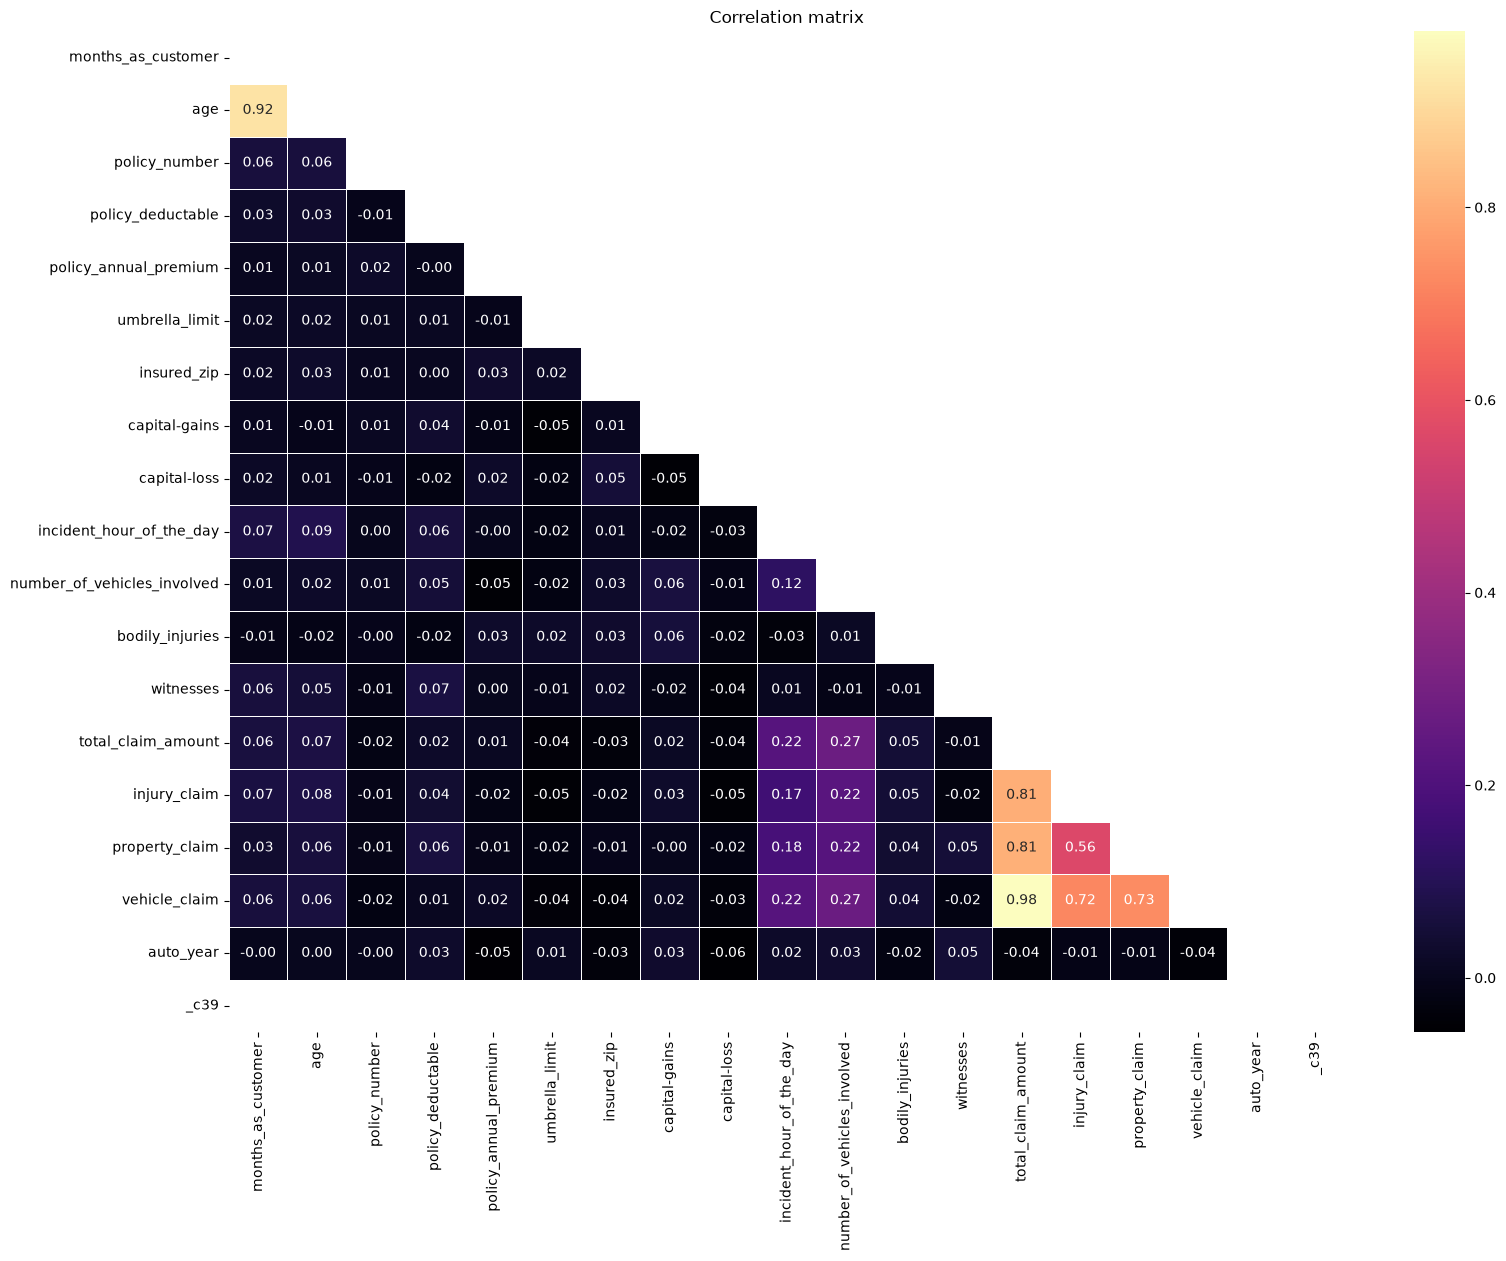

In [60]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 13))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='magma', linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

Correlation Insights the plot indicates a strong correlation between 'age' and 'months_as_customer', so we will drop the 'Age' column.
Additionally, there's a high correlation among 'total_claim_amount', 'injury_claim', 'property_claim', and 'vehicle_claim', since 'total_claim_amount' is the sum of the others.

In [ ]:

to_drop = ['policy_number','policy_bind_date','policy_state','insured_zip','insured_hobbies', '_c39',]

df.drop(to_drop, inplace = True, axis = 1)

We drop Some of the columns because they are not necessary for analysis.

-Now, let's begin the fraud analysis. First, we will compare the differences in fraud occurrences between male and female individuals.

Right here we separates features and target; extracts categorical variables for exploration.


In [12]:
X = df.drop('fraud_reported', axis = 1)
y = df['fraud_reported']

cat_df = X.select_dtypes(include = ['object'])
cat_df.head()

C:\Users\B782ND\AppData\Local\Temp\ipykernel_26680\809310250.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = X.select_dtypes(include = ['object'])


,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_relationship,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,property_damage,police_report_available,auto_make
0,250/500,MALE,MD,craft-repair,husband,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,YES,YES,Saab
1,250/500,MALE,MD,machine-op-inspct,other-relative,2015-01-21,Vehicle Theft,Rear Collision,Minor Damage,Police,VA,NO,NO,Mercedes
2,100/300,FEMALE,PhD,sales,own-child,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,NO,NO,Dodge
3,250/500,FEMALE,PhD,armed-forces,unmarried,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,NO,NO,Chevrolet
4,500/1000,MALE,Associate,sales,unmarried,2015-02-17,Vehicle Theft,Rear Collision,Minor Damage,NaN,NY,NO,NO,Accura


After we displays all unique values present in each categorical column, this help to understand the different categories and values in the data.


In [ ]:


for col in cat_df.columns:
    print(f"{col}: \n{cat_df[col].unique()}\n")

policy_csl: 
<StringArray>
['250/500', '100/300', '500/1000']
Length: 3, dtype: str

insured_sex: 
<StringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str

insured_education_level: 
<StringArray>
['MD', 'PhD', 'Associate', 'Masters', 'High School', 'College', 'JD']
Length: 7, dtype: str

insured_occupation: 
<StringArray>
[     'craft-repair', 'machine-op-inspct',             'sales',
      'armed-forces',      'tech-support',    'prof-specialty',
     'other-service',   'priv-house-serv',   'exec-managerial',
   'protective-serv',  'transport-moving', 'handlers-cleaners',
      'adm-clerical',   'farming-fishing']
Length: 14, dtype: str

insured_relationship: 
<StringArray>
['husband', 'other-relative', 'own-child', 'unmarried', 'wife',
 'not-in-family']
Length: 6, dtype: str

incident_date: 
[datetime.date(2015, 1, 25) datetime.date(2015, 1, 21)
 datetime.date(2015, 2, 22) datetime.date(2015, 1, 10)
 datetime.date(2015, 2, 17) datetime.date(2015, 1, 2)
 datetime.date(2015, 1, 13) date

In [14]:
df = df.astype({col: 'int' for col in df.select_dtypes(include='bool').columns})
cat_df = pd.get_dummies(cat_df, drop_first=True)
print(cat_df.head())

   policy_csl_250/500  policy_csl_500/1000  insured_sex_MALE  \
0                True                False              True   
1                True                False              True   
2               False                False             False   
3                True                False             False   
4               False                 True              True   

   insured_education_level_College  insured_education_level_High School  \
0                            False                                False   
1                            False                                False   
2                            False                                False   
3                            False                                False   
4                            False                                False   

   insured_education_level_JD  insured_education_level_MD  \
0                       False                        True   
1                       False             

In [15]:
num_df = X.select_dtypes(include = ['int64'])
X = pd.concat([num_df, cat_df], axis = 1)
X.head()

,months_as_cusstomer,age,policy_deductable,umbrella_limit,capital_gains,captal_loss,incident_hour_of_the_day,number_of_vehicule_involved,bodily_injuries,witnesses,...,auto_make_Dodge,auto_make_Ford,auto_make_Honda,auto_make_Jeep,auto_make_Mercedes,auto_make_Nissan,auto_make_Saab,auto_make_Suburu,auto_make_Toyota,auto_make_Volkswagen
0,328,48,1000,0,53300,0,5,1,1,2,...,False,False,False,False,False,False,True,False,False,False
1,228,42,2000,5000000,0,0,8,1,0,0,...,False,False,False,False,True,False,False,False,False,False
2,134,29,2000,5000000,35100,0,7,3,2,3,...,True,False,False,False,False,False,False,False,False,False
3,256,41,2000,6000000,48900,-62400,5,1,1,2,...,False,False,False,False,False,False,False,False,False,False
4,228,44,1000,6000000,66000,-46000,20,1,0,1,...,False,False,False,False,False,False,False,False,False,False


See the distribution of each column



C:\Users\B782ND\AppData\Local\Temp\ipykernel_26680\2239138815.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],color='#69d')
C:\Users\B782ND\AppData\Local\Temp\ipykernel_26680\2239138815.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[col],color='#69d')
C:\Users\B782ND\AppData\Lo

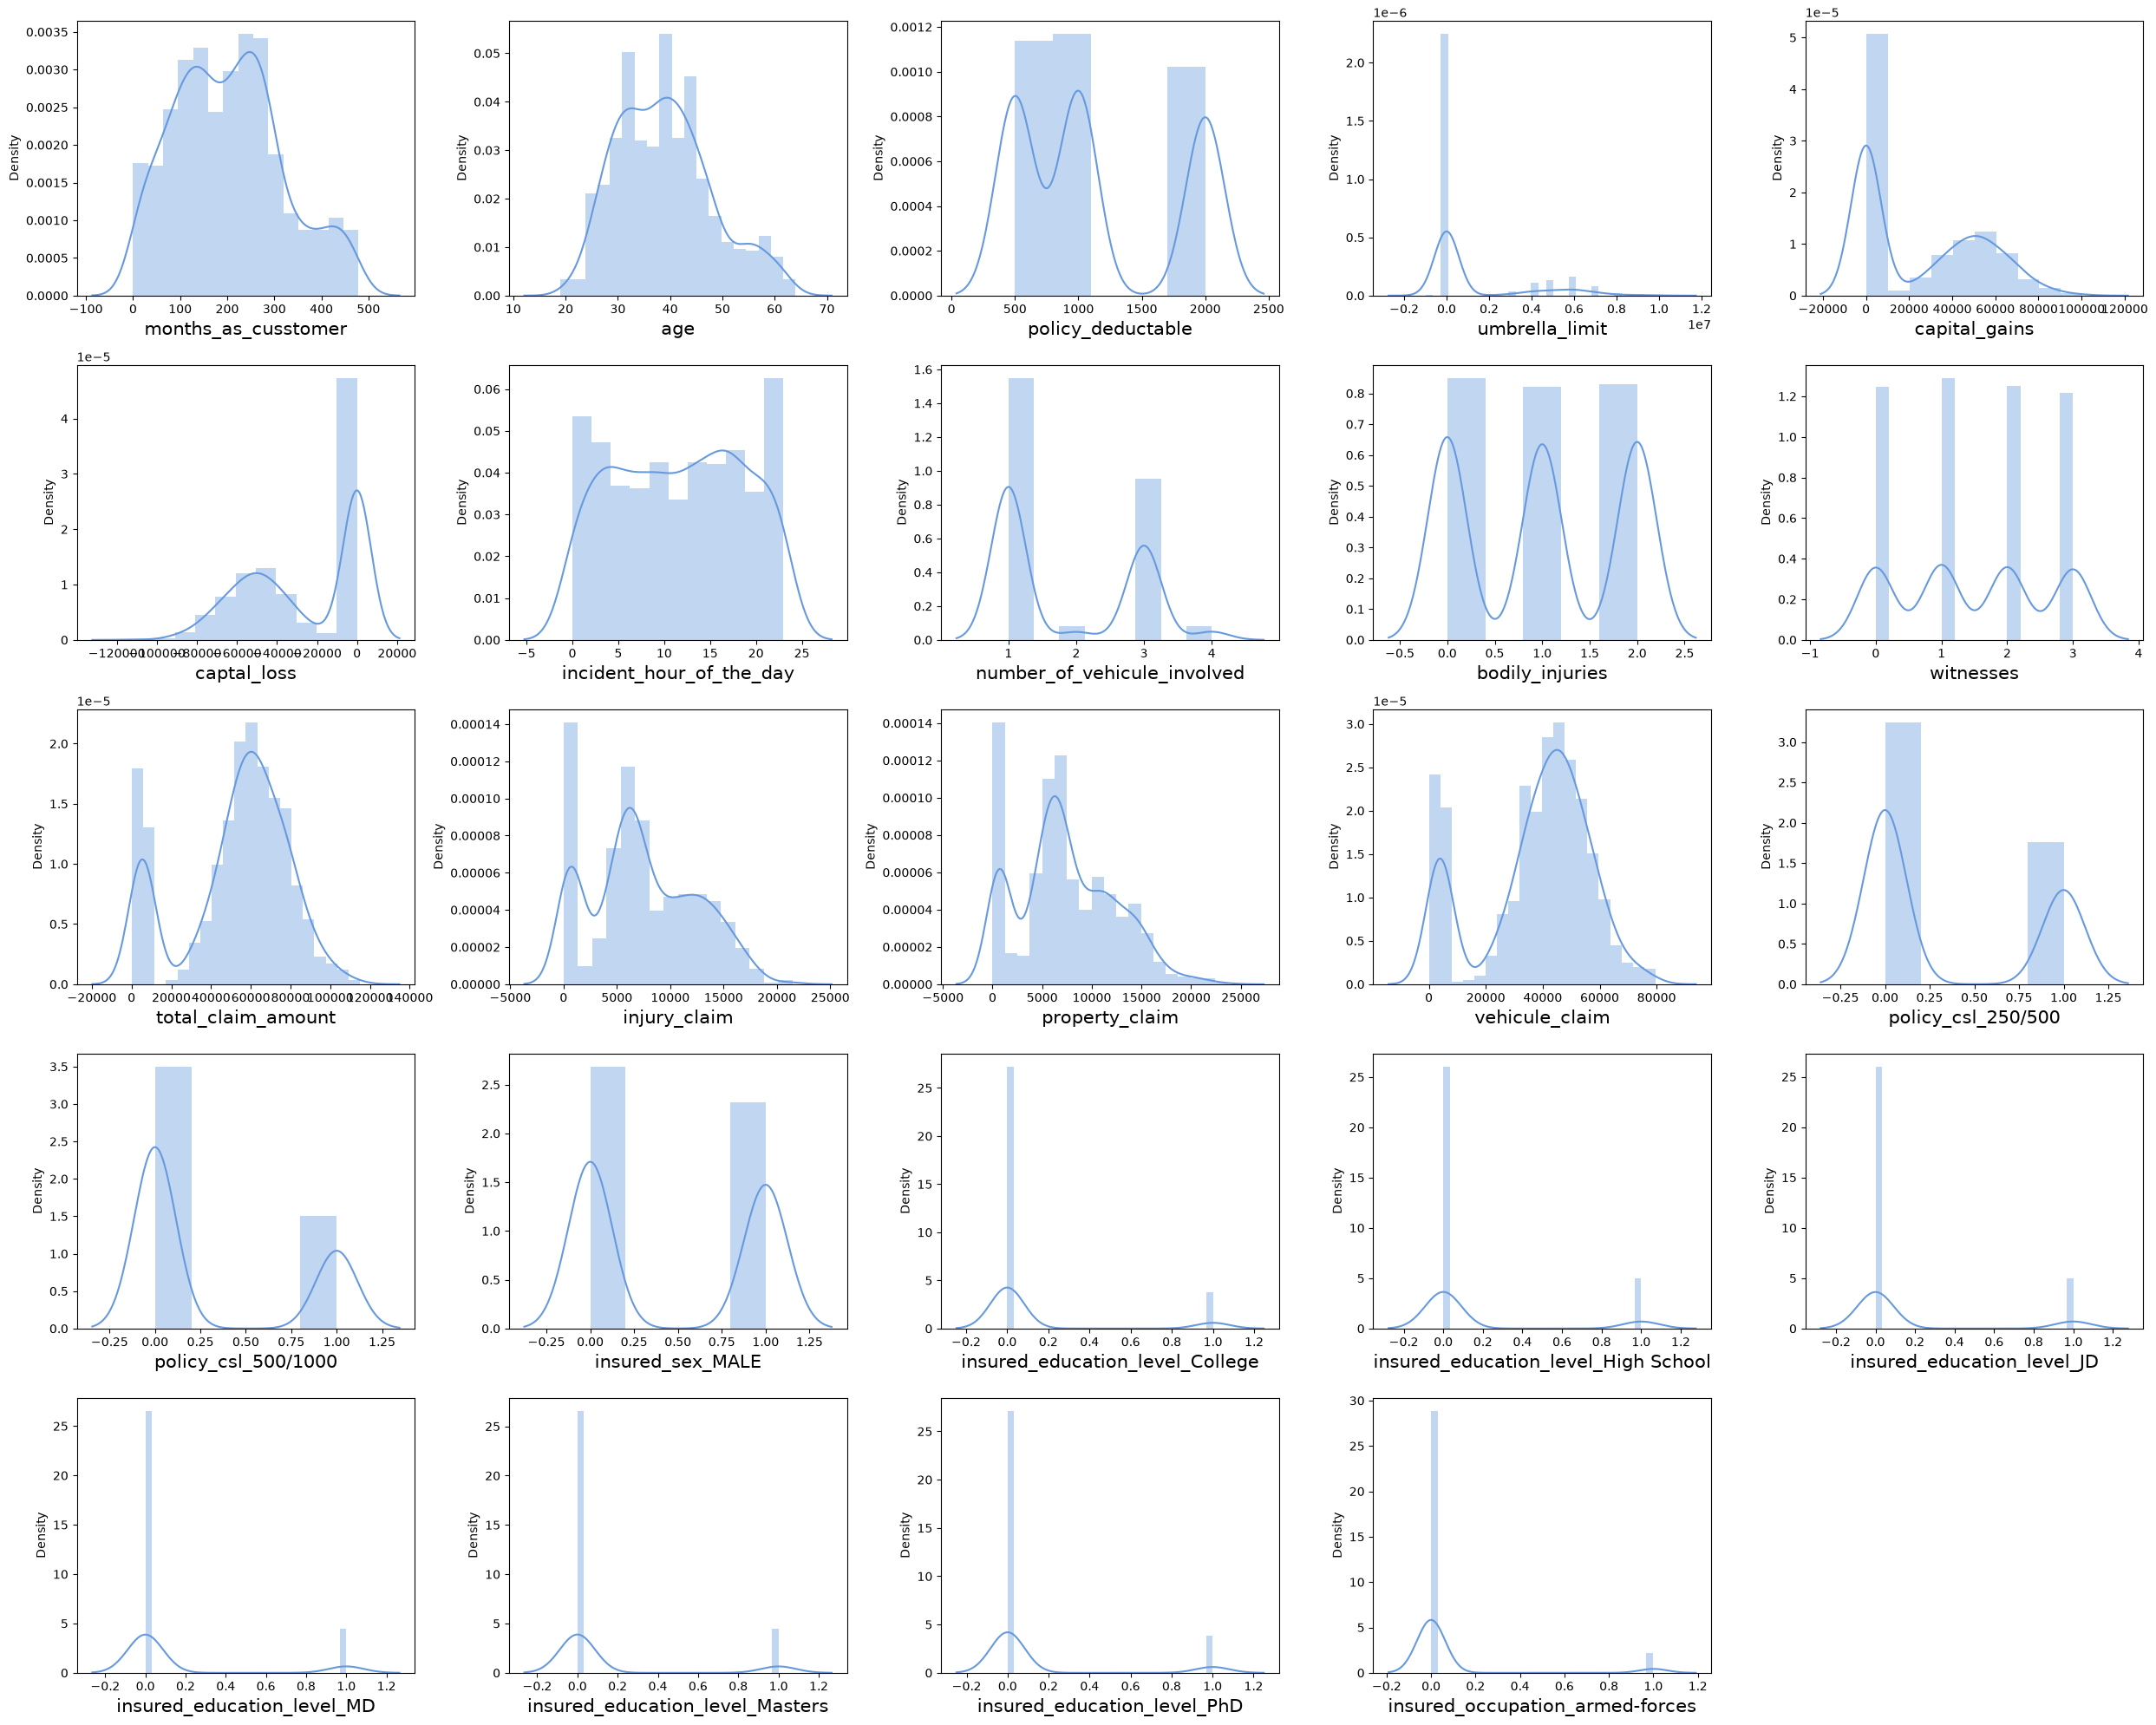

In [16]:
plt.figure(figsize = (25, 20))
plotnumber = 1
for col in X.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.distplot(X[col],color='#69d')
        plt.xlabel(col, fontsize = 15)
        
    plotnumber += 1
    
plt.tight_layout()
plt.show()

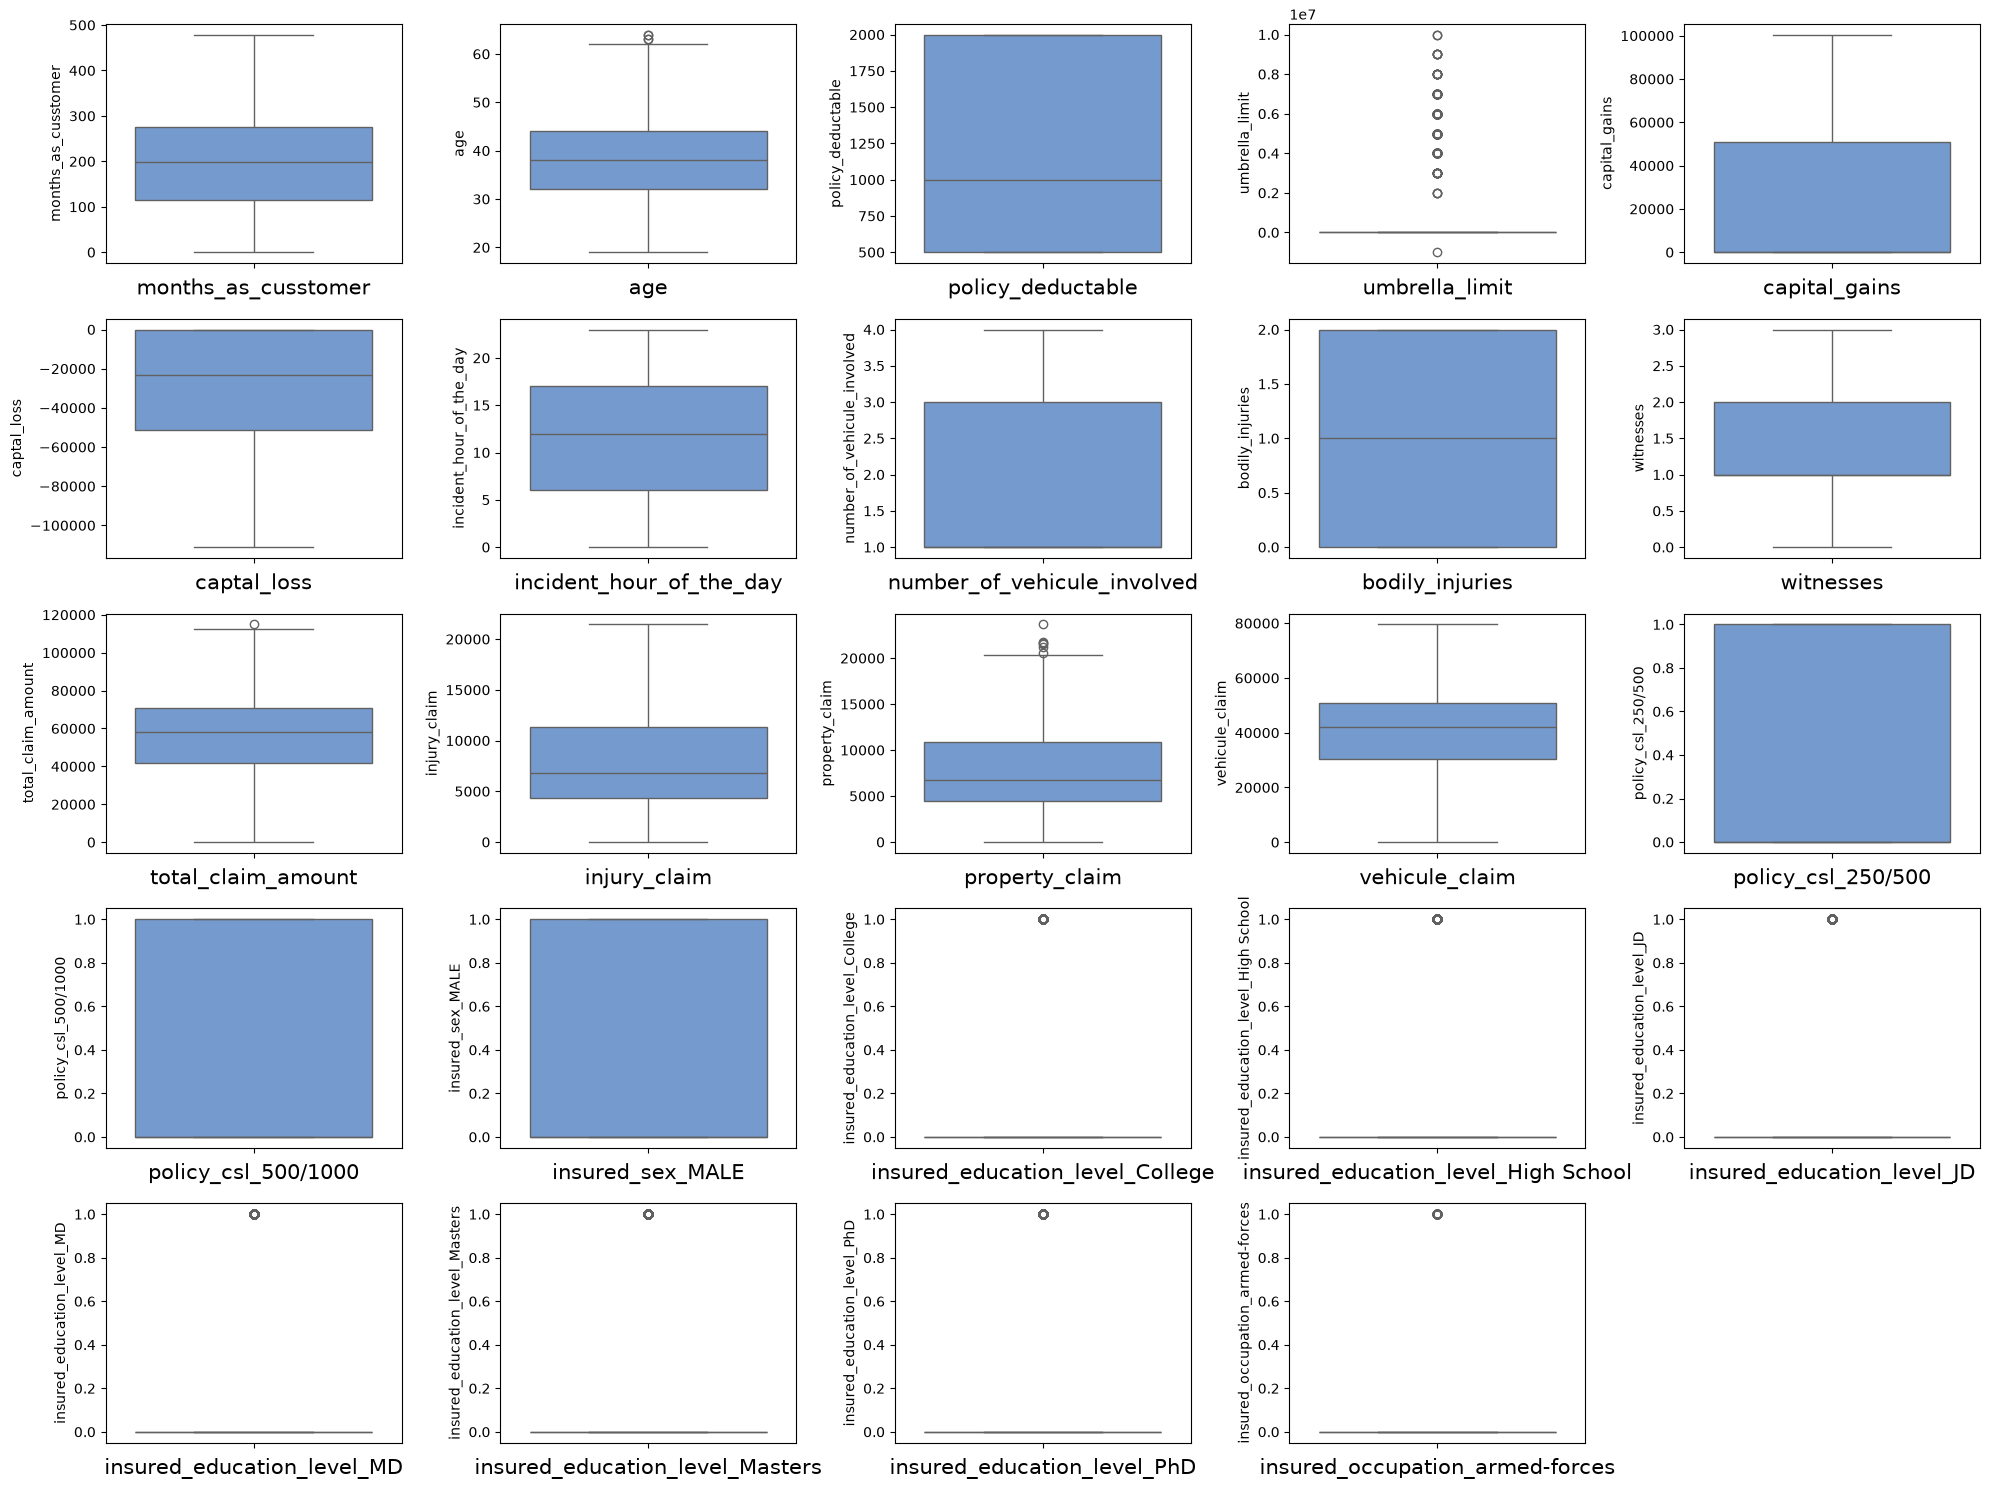

In [70]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for col in X.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(X[col],color='#69d')
        plt.xlabel(col, fontsize = 15)
    
    plotnumber += 1
plt.tight_layout()
plt.show()

Outlier Detection
Assess whether there are outliers in certain columns that may require correction.

-Let's show the total Fraud in this dataset:

In [19]:
fp=pd.DataFrame(df.fraud_reported.value_counts().reset_index().rename(columns={"index":"Report","fraud_reported":"Total"}))
print(fp)


  Total  count
0     N    753
1     Y    247


There are 247 frauds and 753 non-frauds

In [58]:
mf=pd.DataFrame(df.insured_sex.value_counts().reset_index().rename(columns={"Total":"Sex","count":"Total"}))
mf
fig=go.Figure(data=[go.Pie(labels=mf["insured_sex"],
                          values=mf["Total"],
                          hole=.7,
                          title="Total Male and Female",
                          marker_colors=px.colors.sequential.amp_r)])
fig.update_layout(title="Male & Female :")

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig.update_layout(margin=dict(t=60, b=0, l=50, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=400,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=25, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))
                 


fig.show()


The distribution between the percentage of men and women who commit fraud is quite similar, with a slight tendency towards women.

-Lets Show the Total Claim amount Vs Fraud Reported According to Male & Female

In [21]:
fig=px.box(df,x='insured_sex',y='total_claim_amount',color='fraud_reported',notched=True,template='plotly_dark')
fig.show()

Fraud by Women is slighty more compared to men

-Let's show the Maximum fraud_reported Vs occupation

In [22]:
occ=pd.DataFrame(df.groupby(["insured_occupation"])["fraud_reported"].value_counts().sort_values(ascending=False).reset_index(name="Total"))
occ=occ[occ["fraud_reported"]=='Y']

fig=px.bar(occ,x="insured_occupation",y='Total',text='Total',color="fraud_reported",title="Maximum Fraud Vs Occupations:")

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig.update_layout(margin=dict(t=80, b=40, l=30, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=400,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=25, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=14, font_family="Lato, sans-serif"))

fig.show()

Most of the Fraud Cases found in Exec_managerial and tech Support

-Let's how Maximum Insured Education Level

In [23]:
ins_ed_lv=pd.DataFrame(df["insured_education_level"].value_counts().reset_index().rename(columns={"Total":"Insured_education_level","count":"Total"}))
ins_ed_lv


,insured_education_level,Total
0,JD,161
1,High School,160
2,Associate,145
3,MD,144
4,Masters,143
5,PhD,125
6,College,122


In [24]:

fig_tree=px.treemap(ins_ed_lv,path=[px.Constant("Education Level"),"insured_education_level","Total",])
fig_tree.update_layout(title="Insured Education Level",
                      margin=dict(t=50,b=0,l=70,r=40),
                      plot_bgcolor="#333",paper_bgcolor="#333",
                      title_font=dict(size=25,color="#fff",family="Lato,sans-serif"),
                      font=dict(color="#8a8d93"),
                      hoverlabel=dict(bgcolor="#444",font_size=13,font_family="Lato,sans_serif"))
fig_tree.show()
fig.show()

                 

Fraudsters are most people from JD and High School in this dataset based on education and and exec-managers are the biggest fraudsters if we look at the jobs

-Let's Show the Which State has the Most Incident:

In [25]:
i_state=pd.DataFrame(df["incident_state"].value_counts().reset_index().rename(columns={"Total":"incident_state","count":"Total"}))
i_state

,incident_state,Total
0,NY,262
1,SC,248
2,WV,217
3,VA,110
4,NC,110
5,PA,30
6,OH,23


In [26]:
fig = px.bar(i_state,x="incident_state", y='Total',
      title = 'Total Incident',template="plotly_dark",text="Total")
fig1=go.Figure(data=[go.Pie(labels=i_state["incident_state"],
                           values=i_state["Total"],
                           hole=0.4,
                           title="Total Incident Each State",
                           marker_colors=px.colors.sequential.Plotly3)])

fig1.update_layout(title="Incident All States:")
fig1.update_xaxes(showgrid=False)
fig1.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)
fig1.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))
fig1.update_layout(margin=dict(t=80, b=0, l=70, r=40),hovermode="y unified", xaxis_title=' ', yaxis_title=" ", height=350,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=21, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'), legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5), hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))          

fig.show()
fig1.show()


New York is the area with the most fraudsters closely followed by south carolina

-Which Month has the More Incidents ? 

In [45]:
df["incident_date"]=pd.to_datetime(df["incident_date"])
df["Year"]=df["incident_date"].dt.year
df["Month_no"]=df["incident_date"].dt.month
df['MonthName']=df["incident_date"].dt.month_name()


incident=pd.DataFrame(df.groupby(["incident_state"])["MonthName"].value_counts().reset_index(name="Count").sort_values(by="Count",ascending=False))
J_incident=incident[incident["MonthName"]=="January"]
f_incident=incident[incident["MonthName"]=="February"]
m_incident=incident[incident["MonthName"]=="March"]

In [ ]:
fig=go.Figure()
fig11=go.Figure()
fig12=go.Figure()
fig.add_trace(go.Scatter(x=J_incident["incident_state"],y=J_incident["Count"],marker_color="darkblue"))



my_button=list(
    [
        dict(args=["type","bar"],label="Bar Plot",method="restyle"),
        dict(args=["type","Scatter"],label="Scatter Plot",method="restyle")
    
]
)

fig.update_layout(
    updatemenus=[dict(type="buttons",buttons=my_button,direction="left",
                      pad={"r":0,"t":0.1},
                      showactive=True,
                      xanchor="left",x=0.4,
                      yanchor="top",y=0.95
                     )]
)


fig.update_layout(title="State Incidents In Month of January:")

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig.update_layout(margin=dict(t=80, b=0, l=70, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=350,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=21, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))

fig11.add_trace(go.Scatter(x=f_incident["incident_state"],y=f_incident["Count"],marker_color="darkred"))



my_button=list(
    [
        dict(args=["type","bar"],label="Bar Plot",method="restyle"),
        dict(args=["type","Scatter"],label="Scatter Plot",method="restyle")
    
]
)

fig11.update_layout(
    updatemenus=[dict(type="buttons",buttons=my_button,direction="left",
                      pad={"r":0,"t":0.1},
                      showactive=True,
                      xanchor="left",x=0.4,
                      yanchor="top",y=0.95
                     )]
)


fig11.update_layout(title="State Incidents In Month of February:")

fig11.update_xaxes(showgrid=False)

fig11.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig11.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig11.update_layout(margin=dict(t=80, b=0, l=70, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=350,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=21, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))

fig12.add_trace(go.Scatter(x=m_incident["incident_state"],y=m_incident["Count"],marker_color="silver"))



my_button=list(
    [
        dict(args=["type","bar"],label="Bar Plot",method="restyle"),
        dict(args=["type","Scatter"],label="Scatter Plot",method="restyle")
    
]
)

fig12.update_layout(
    updatemenus=[dict(type="buttons",buttons=my_button,direction="left",
                      pad={"r":0,"t":0.1},
                      showactive=True,
                      xanchor="left",x=0.4,
                      yanchor="top",y=0.95
                     )]
)


fig12.update_layout(title="State Incidents In Month of March:")

fig12.update_xaxes(showgrid=False)

fig12.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig12.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig12.update_layout(margin=dict(t=80, b=0, l=70, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=350,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=21, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))








fig.show()
fig11.show()
fig12.show()


In [29]:
month_f=pd.DataFrame(df.groupby(["MonthName"])["fraud_reported"].value_counts().reset_index(name="Total").sort_values(by="Total",ascending=False))


fig=px.line(month_f,x="MonthName",y="Total",color="fraud_reported",title="Which month has the Most Fraud nor Not",
           template="plotly_dark",
           labels={"Updated On":"Date"})

fig.show()


Maximum Fraud Cases are from January and February

In [30]:
inc_f=pd.DataFrame(df.groupby(["incident_state"])["fraud_reported"].value_counts().reset_index(name="Total"))


fig=px.bar(inc_f,x="incident_state",y='Total',color="fraud_reported",title="Incidents Vs Fraud Reports:")

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig.update_layout(margin=dict(t=80, b=40, l=30, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=400,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=25, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=14, font_family="Lato, sans-serif"))

fig.show()


More Frauds in New York and SC States

Which State has the most Police Report available:

In [31]:
p_state=pd.DataFrame(df.groupby(["incident_state"])["police_report_available"].count().reset_index())


fig=px.pie(p_state,names='incident_state',values="police_report_available",color_discrete_sequence=px.colors.sequential.RdBu,hole=.3)

fig.update_layout(title="Police Reports Vs State:")

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None, marker=dict(line=dict(width=0)))

fig.update_layout(margin=dict(t=80, b=0, l=70, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=350,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=21, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))




fig.show()


-Now, let's take a closer look at the damage report data we have in our dataset.

In [33]:
incident_severity=pd.DataFrame(df["incident_severity"].value_counts().reset_index().rename(columns={"Total":"incident_severity","count":"Total"}))
cnf, dth, rec, act = '#393e46', '#ff2e63', '#21bf73', '#fe9801' 

fig=px.treemap(incident_severity,path=["incident_severity"],values="Total",height=255,color_discrete_sequence=[act,rec,dth])
fig.data[0].textinfo="label+text+value"


fig.show()


Four categories ranging from minor damage to trivial damage and there are Total 354 are Minor Damage and Total Loss 280 and Major Damage is 276 or Trivial Damage 90

-Show the incident severity Vs Fraud Reported

In [34]:
inc_ser=pd.DataFrame(df.groupby(["incident_severity"])["fraud_reported"].value_counts().reset_index(name="Total"))
inc_ser=inc_ser.sort_values(by="Total",ascending=False)
inc_ser.rename(columns={"incident_severity":"incidentseverity","fraud_reported":"fraudreported"},inplace=True)



fig1 = go.Figure(data = [go.Table(header = dict(values = list(inc_ser.columns),
                                               align = "left",
                                               line_color = "black",
                                               fill_color = "#62F939"),
                                 cells = dict(values = [inc_ser.incidentseverity, inc_ser.fraudreported, inc_ser.Total],
                                              align = "left",
                                              line_color = "black",
                                              fill_color = "#A4FA8C"))])
 

fig1.show()


-Let's the Car Vs Frauds

In [35]:
make =pd.DataFrame(df.groupby('auto_make')['fraud_reported'].value_counts().reset_index(name="Total"))
make=make[make["fraud_reported"]=="Y"]
make.sort_values(by="Total",ascending=False,inplace=True)




colors = ["#00e617"]
fig = px.scatter(make, x = "auto_make", y = "Total" ,color_discrete_sequence=px.colors.sequential.Electric)
fig.update_layout(title = "Which car has the Most Fraud Cases", xaxis_title="States",yaxis_title= "", plot_bgcolor="#fff", showlegend = False)

fig.add_trace(go.Scatter(x=make["auto_make"],y=make["Total"],marker_color="darkred"))


fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hoverlabel=None)

fig.update_layout(margin=dict(t=60, b=0, l=50, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=400,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=25, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))
fig.show()


Most of the Fraud Cases found in Ford and Mercedex & Audi



-Show the Capital Loss Vs States

In [74]:
capital_loss=df.groupby(["incident_state"])["capital-loss"].sum().reset_index()



fig = go.Figure(go.Waterfall(
    name = "20", orientation = "v",

    x =capital_loss["incident_state"],
    textposition = "outside",
    text = capital_loss["capital-loss"],
    y =capital_loss["capital-loss"],
    connector = {"line":{"color":"hsl(63, 63, 63)"}},
))

fig.update_layout(
        title = "Capital Loss According To States:",
        showlegend = True
)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None)

fig.update_layout(margin=dict(t=60, b=0, l=50, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=400,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=25, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))
                 




fig.show()


Maximum capital loss in New York City

-States incident incident_hour_of_the_day

In [47]:
per_hs=df.groupby(["incident_state"])["incident_hour_of_the_day"].sum().sort_values(ascending=False).reset_index()


colors = ["#00e617"]
fig = px.bar(per_hs, x = "incident_state", y = "incident_hour_of_the_day" ,color_discrete_sequence=px.colors.sequential.Electric)
fig.update_layout(title = "States Incident Per Hour of the Day", xaxis_title="States",yaxis_title= "", plot_bgcolor="#fff", showlegend = False)

fig.add_trace(go.Scatter(x=per_hs["incident_state"],y=per_hs["incident_hour_of_the_day"],marker_color="darkred"))


fig.update_xaxes(showgrid=False)

fig.update_yaxes(showgrid=False, categoryorder='total ascending', ticksuffix=' ', showline=False)

fig.update_traces(hovertemplate=None)

fig.update_layout(margin=dict(t=60, b=0, l=50, r=40),hovermode="y unified",
                  xaxis_title=' ', yaxis_title=" ", height=400,plot_bgcolor='#333', paper_bgcolor='#333',
title_font=dict(size=25, color='#8a8d93', family="Lato, sans-serif"),
 font=dict(color='#8a8d93'),
                  legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="right", x=0.5),
                  hoverlabel=dict(bgcolor="black", font_size=13, font_family="Lato, sans-serif"))
fig.show()


Most Incidents per in New York City